# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ashiba713/flyrank-ml-internship/blob/main/work/notebooks/capstone.ipynb)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question

*The research question and the decision it supports.*

In [1]:
question = """
Can historical search-performance and query-mix signals be used
to rank content pages that appear most worth reviewing for a
potential refresh?
"""

decision = """
The output supports an editor's decision about which content pages
to review first. It is decision support, not a claim about Google's
ranking algorithm or a causal effect of refreshing content.
"""

print("Research question:")
print(question)
print("\nDecision supported:")
print(decision)

Research question:

Can historical search-performance and query-mix signals be used
to rank content pages that appear most worth reviewing for a
potential refresh?


Decision supported:

The output supports an editor's decision about which content pages
to review first. It is decision support, not a claim about Google's
ranking algorithm or a causal effect of refreshing content.



## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

In [2]:
# Capstone data contract

data_description = """
Dataset:
FlyRank ML Internship search/discoverability warehouse release.

Tables used:
- dim_clients
- dim_content
- fact_daily
- fact_content_query_90d

Unit of analysis:
One row represents one content item for the modeling dataset.

Time windows:
- Historical performance signals are aggregated into pre-outcome windows.
- Query-level signals come from the available 90-day query summary.
- The exact date bounds are read from the warehouse rather than assumed.

Included signals:
- Historical impressions and clicks
- Average search position
- Visible query count
- Rare-impression share
- Anonymized-impression share
- Top-query impression concentration

Excluded from model features:
- Client/content identifiers: used only for grouping and joining.
- trend_direction and trend_pct: label-derived information and therefore leakage.
- Any future-window outcome fields: these would reveal the answer being predicted.
- Client names, domains, URLs, private queries, credentials, and raw exports:
  not included because the public capstone must remain client-safe.

Public-safety rule:
Only anonymized/aggregate information is used in the public analysis.
No client-identifying details are published.
"""

print(data_description)


Dataset:
FlyRank ML Internship search/discoverability warehouse release.

Tables used:
- dim_clients
- dim_content
- fact_daily
- fact_content_query_90d

Unit of analysis:
One row represents one content item for the modeling dataset.

Time windows:
- Historical performance signals are aggregated into pre-outcome windows.
- Query-level signals come from the available 90-day query summary.
- The exact date bounds are read from the warehouse rather than assumed.

Included signals:
- Historical impressions and clicks
- Average search position
- Visible query count
- Rare-impression share
- Anonymized-impression share
- Top-query impression concentration

Excluded from model features:
- Client/content identifiers: used only for grouping and joining.
- trend_direction and trend_pct: label-derived information and therefore leakage.
- Any future-window outcome fields: these would reveal the answer being predicted.
- Client names, domains, URLs, private queries, credentials, and raw exports:
 

In [4]:
# ============================================
# CAPSTONE DATA SETUP
# ============================================

%pip -q install duckdb huggingface_hub

import os
import getpass
import duckdb

# Enter your Hugging Face READ token securely.
HF_TOKEN = os.environ.get("HF_TOKEN") or getpass.getpass(
    "Paste your Hugging Face READ token (hf_...): "
)

# Connect DuckDB
con = duckdb.connect()

# Authenticate with Hugging Face
con.execute(
    f"CREATE OR REPLACE SECRET hf "
    f"(TYPE huggingface, TOKEN '{HF_TOKEN}')"
)

# Full FlyRank warehouse
REL = "hf://datasets/FlyRank/internship-warehouse"

TABLES = {
    "dim_clients": f"read_parquet('{REL}/dim_clients.parquet')",
    "dim_content": f"read_parquet('{REL}/dim_content.parquet')",
    "fact_daily": f"read_parquet('{REL}/fact_content_daily_performance/**/*.parquet')",
    "fact_daily_sample": f"read_parquet('{REL}/fact_content_daily_performance_sample.parquet')",
    "fact_query_90d": f"read_parquet('{REL}/fact_content_query_90d.parquet')",
}

print("✅ FlyRank warehouse connection ready")
print("\nAvailable tables:")

for name in TABLES:
    print(" -", name)

Paste your Hugging Face READ token (hf_...): ··········
✅ FlyRank warehouse connection ready

Available tables:
 - dim_clients
 - dim_content
 - fact_daily
 - fact_daily_sample
 - fact_query_90d


In [5]:
# ============================================
# VERIFY THE DATA USED BY THE CAPSTONE
# ============================================

print("=== WAREHOUSE TABLES ===")

for name, src in TABLES.items():
    print(f"\n{name}")
    print(con.sql(f"DESCRIBE SELECT * FROM {src}").df()[["column_name", "column_type"]].to_string(index=False))


print("\n=== DAILY PERFORMANCE WINDOW ===")

daily_check = con.sql(f"""
    SELECT
        MIN(report_date) AS start_date,
        MAX(report_date) AS end_date,
        COUNT(DISTINCT client_hash_id) AS clients,
        COUNT(DISTINCT content_hash_id) AS content_items
    FROM {TABLES['fact_daily']}
""").df()

display(daily_check)


print("\n=== QUERY SUMMARY ===")

query_check = con.sql(f"""
    SELECT
        COUNT(DISTINCT content_hash_id) AS content_items,
        COUNT(*) AS query_rows
    FROM {TABLES['fact_query_90d']}
""").df()

display(query_check)


print("\n✅ Data verification complete.")

=== WAREHOUSE TABLES ===

dim_clients
        column_name column_type
     client_hash_id     VARCHAR
          is_active     BOOLEAN
     has_gsc_access     BOOLEAN
     has_ga4_access     BOOLEAN
     access_profile     VARCHAR
client_created_date        DATE
client_updated_date        DATE
     gsc_data_start        DATE
     ga4_data_start        DATE

dim_content
               column_name column_type
            client_hash_id     VARCHAR
           content_hash_id     VARCHAR
           keyword_hash_id     VARCHAR
               url_hash_id     VARCHAR
        keyword_char_count      BIGINT
       keyword_token_count      BIGINT
            url_char_count      BIGINT
      content_created_date        DATE
      content_updated_date        DATE
              content_type     VARCHAR
             search_volume      BIGINT
               competition      DOUBLE
         competition_level     VARCHAR
                       cpc      DOUBLE
               main_intent     VARCHAR
     

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,start_date,end_date,clients,content_items
0,2025-01-27,2026-06-30,70,427292



=== QUERY SUMMARY ===


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,content_items,query_rows
0,133852,2414248



✅ Data verification complete.


### Data

This capstone uses the FlyRank ML Internship warehouse release hosted on Hugging Face.

The analysis uses the following public-safe tables:

- `fact_content_daily_performance` — daily content-performance measurements.
- `fact_content_query_90d` — aggregated query-level signals for content items.
- `dim_content` — content-level metadata used only where needed.
- `dim_clients` — client-level context used for grouping and validation, not as a model feature.

The daily performance data is used to construct historical performance features and the outcome window. Query-level data is aggregated to the content-item level before modeling.

Client names, domains, URLs, private search queries, credentials, and raw exports are not used or published. Pseudonymous client and content identifiers are used only for joining, grouping, and validation.

The analysis also excludes fields that are derived from the outcome or contain future information. In particular, label-derived fields such as `trend_direction` and `trend_pct` are not used as model features because they could leak information about the outcome.

All reported results are based on the data available in the selected warehouse release and analysis windows.

In [6]:
# Confirm the analysis grain before modeling

grain_check = con.sql(f"""
    SELECT
        client_hash_id,
        content_hash_id,
        COUNT(*) AS n
    FROM {TABLES['fact_daily']}
    GROUP BY client_hash_id, content_hash_id
    HAVING COUNT(*) < 1
    LIMIT 5
""").df()

print("Grain check complete.")
print(f"Unexpected empty groups: {len(grain_check)}")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Grain check complete.
Unexpected empty groups: 0


## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

### Methodology

#### Approach

This project uses supervised machine learning to rank content items that may be worth editorial review.

The model uses historical search-performance and query-mix signals that are available before the outcome window. The goal is decision support: identify pages that appear more likely to need review, rather than claim to predict Google's ranking algorithm.

#### Features

The candidate features are:

- `imp_last30` — impressions during the most recent 30-day feature window.
- `imp_prev30` — impressions during the preceding 30-day window.
- `clk_last30` — clicks during the most recent 30-day window.
- `pos_last30` — average search position during the most recent 30-day window.
- `visible_queries` — number of queries with visible search activity.
- `rare_share` — share of impressions associated with rare queries.
- `anon_share` — share of impressions associated with anonymized queries.
- `top_query_impressions` — impressions from the highest-impression query.
- `kept_impressions` — impressions retained after query-level filtering.

Client and content identifiers are used only for grouping, joining, and validation. They are not model features.

#### Label

The outcome label identifies content items whose subsequent impressions declined substantially relative to the preceding period.

Label-derived fields such as `trend_direction` and `trend_pct` are excluded from the feature matrix because they contain information about the outcome.

#### Baseline

The model is compared with a transparent baseline using the same evaluation data and metric. The baseline provides a simple reference point so that additional model complexity must demonstrate measurable value.

#### Validation

The evaluation uses a grouped train/test split by `client_hash_id`. This prevents pages from the same client appearing in both training and test sets, reducing the risk that the model benefits from client-specific patterns that would not generalize.

#### Leakage checks

Features are restricted to information available before the outcome window. Outcome-derived fields, future-window measurements, and identifiers are excluded from model training.

In [7]:
# Inspect the columns available for the capstone target and features

print("Daily performance columns:")
display(
    con.sql(f"DESCRIBE SELECT * FROM {TABLES['fact_daily']}")
    .df()
)

print("\nQuery-level columns:")
display(
    con.sql(f"DESCRIBE SELECT * FROM {TABLES['fact_query_90d']}")
    .df()
)

Daily performance columns:


,column_name,column_type,null,key,default,extra
0,report_date,DATE,YES,None,None,None
1,client_hash_id,VARCHAR,YES,None,None,None
2,content_hash_id,VARCHAR,YES,None,None,None
3,client_has_gsc,BOOLEAN,YES,None,None,None
4,client_has_ga4,BOOLEAN,YES,None,None,None
5,gsc_data_available,BOOLEAN,YES,None,None,None
6,ga4_data_available,BOOLEAN,YES,None,None,None
7,gsc_impressions,BIGINT,YES,None,None,None
8,gsc_clicks,BIGINT,YES,None,None,None
9,gsc_sum_position,BIGINT,YES,None,None,None



Query-level columns:


,column_name,column_type,null,key,default,extra
0,client_hash_id,VARCHAR,YES,None,None,None
1,content_hash_id,VARCHAR,YES,None,None,None
2,query_hash_id,VARCHAR,YES,None,None,None
3,query_char_count,BIGINT,YES,None,None,None
4,query_token_count,BIGINT,YES,None,None,None
5,window_start,DATE,YES,None,None,None
6,window_end,DATE,YES,None,None,None
7,impressions_90d,BIGINT,YES,None,None,None
8,clicks_90d,BIGINT,YES,None,None,None
9,impressions_last30,BIGINT,YES,None,None,None


In [9]:
# ============================================
# 3A. BUILD CAPSTONE FEATURES + LABEL
# ============================================

# We use the latest available date as the reference point.
# The previous 30 days are our feature window.
# The following 30 days are our outcome window.

bounds = con.sql(f"""
    SELECT MAX(report_date) AS end_date
    FROM {TABLES['fact_daily']}
""").fetchone()[0]

print("Latest available date:", bounds)

features = con.sql(f"""
WITH bounds AS (
    SELECT MAX(report_date) AS end_date
    FROM {TABLES['fact_daily']}
),

daily AS (
    SELECT
        client_hash_id,
        content_hash_id,

        SUM(
            CASE
                WHEN report_date > end_date - INTERVAL 30 DAY
                THEN gsc_impressions ELSE 0
            END
        ) AS impressions_last30,

        SUM(
            CASE
                WHEN report_date <= end_date - INTERVAL 30 DAY
                AND report_date > end_date - INTERVAL 60 DAY
                THEN gsc_impressions ELSE 0
            END
        ) AS impressions_prev30,

        SUM(
            CASE
                WHEN report_date > end_date - INTERVAL 30 DAY
                THEN gsc_clicks ELSE 0
            END
        ) AS clicks_last30,

        AVG(
            CASE
                WHEN report_date > end_date - INTERVAL 30 DAY
                THEN gsc_avg_position
            END
        ) AS avg_position_last30

    FROM {TABLES['fact_daily']}, bounds

    WHERE report_date > end_date - INTERVAL 60 DAY

    GROUP BY client_hash_id, content_hash_id
),

query_features AS (
    SELECT
        client_hash_id,
        content_hash_id,

        MAX(content_visible_query_count) AS visible_queries,
        MAX(rare_impressions_share) AS rare_share,
        MAX(anonymized_impressions_share) AS anonymized_share,
        MAX(content_total_impressions_90d) AS query_impressions_90d

    FROM {TABLES['fact_query_90d']}

    GROUP BY client_hash_id, content_hash_id
)

SELECT
    d.*,
    q.visible_queries,
    q.rare_share,
    q.anonymized_share,
    q.query_impressions_90d

FROM daily d
LEFT JOIN query_features q
    USING (client_hash_id, content_hash_id)

WHERE d.impressions_prev30 >= 100
""").df()

print(f"Modeling rows: {len(features):,}")
display(features.head())

Latest available date: 2026-06-30


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Modeling rows: 111,247


,client_hash_id,content_hash_id,impressions_last30,impressions_prev30,clicks_last30,avg_position_last30,visible_queries,rare_share,anonymized_share,query_impressions_90d
0,client_08a6a72ff48e62c0,content_5f71205e0b46f70a,2479.0,3341.0,5.0,6.314476,12,0.036253,0.910266,8358
1,client_08a6a72ff48e62c0,content_5f716493f7989b45,200.0,584.0,0.0,17.358072,17,0.095416,0.650608,2138
2,client_08a6a72ff48e62c0,content_5f93f846d9834caf,159.0,375.0,0.0,42.214530,2,0.415631,0.539964,563
3,client_08a6a72ff48e62c0,content_5fb5bd16c7ad75f1,111.0,383.0,0.0,42.120529,8,0.339869,0.303268,765
4,client_08a6a72ff48e62c0,content_5fb962ebc3de35af,82.0,136.0,0.0,39.862891,4,0.445545,0.306931,303


In [10]:
# ============================================
# 3B. DEFINE THE OUTCOME LABEL
# ============================================

# Decline = at least a 20% drop in impressions
features["impression_change_pct"] = (
    (features["impressions_last30"] - features["impressions_prev30"])
    / features["impressions_prev30"]
)

features["declined"] = (
    features["impression_change_pct"] <= -0.20
).astype(int)

print("Outcome definition:")
print("declined = 1 when impressions fell by at least 20%")
print("declined = 0 otherwise")

print("\nClass distribution:")
display(
    features["declined"]
    .value_counts(normalize=False)
    .rename("count")
    .to_frame()
)

print("\nClass proportions:")
display(
    (features["declined"].value_counts(normalize=True) * 100)
    .round(2)
    .rename("percent")
    .to_frame()
)

Outcome definition:
declined = 1 when impressions fell by at least 20%
declined = 0 otherwise

Class distribution:


,count
declined,
1,71592
0,39655



Class proportions:


,percent
declined,
1,64.35
0,35.65


In [11]:
# ============================================
# 3C. BASELINE
# ============================================

# Simple baseline:
# Always predict the majority class (declined = 1)

baseline_prediction = 1

features["baseline_pred"] = baseline_prediction

baseline_accuracy = (
    features["declined"] == features["baseline_pred"]
).mean()

print("Baseline: always predict 'declined'")
print(f"Baseline accuracy: {baseline_accuracy:.4f}")
print(f"Baseline accuracy: {baseline_accuracy * 100:.2f}%")
print(f"Majority-class base rate: {features['declined'].mean() * 100:.2f}%")

Baseline: always predict 'declined'
Baseline accuracy: 0.6435
Baseline accuracy: 64.35%
Majority-class base rate: 64.35%


In [12]:
# ============================================
# 3D. PREPARE FEATURES + GROUPED SPLIT
# ============================================

from sklearn.model_selection import GroupShuffleSplit

# These are the features the model is allowed to use.
feature_columns = [
    "impressions_last30",
    "impressions_prev30",
    "clicks_last30",
    "avg_position_last30",
    "visible_queries",
    "rare_share",
    "anonymized_share",
    "query_impressions_90d"
]

X = features[feature_columns].copy()
y = features["declined"].copy()

# Remove rows with missing feature values.
valid = X.notna().all(axis=1)

X = X.loc[valid]
y = y.loc[valid]
groups = features.loc[valid, "client_hash_id"]

print(f"Rows available for modeling: {len(X):,}")
print(f"Features used: {len(feature_columns)}")
print("\nFeatures:")
for f in feature_columns:
    print(" -", f)

# --------------------------------------------
# GROUPED TRAIN / TEST SPLIT
# --------------------------------------------

gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

train_idx, test_idx = next(
    gss.split(X, y, groups=groups)
)

X_train = X.iloc[train_idx]
X_test = X.iloc[test_idx]

y_train = y.iloc[train_idx]
y_test = y.iloc[test_idx]

groups_train = groups.iloc[train_idx]
groups_test = groups.iloc[test_idx]

print("\n=== SPLIT ===")
print(f"Training rows: {len(X_train):,}")
print(f"Testing rows:  {len(X_test):,}")

print(f"\nTraining clients: {groups_train.nunique():,}")
print(f"Testing clients:  {groups_test.nunique():,}")

# Confirm there is NO client overlap.
overlap = set(groups_train.unique()) & set(groups_test.unique())

print(f"\nClient overlap: {len(overlap)}")

assert len(overlap) == 0, "LEAKAGE: clients appear in both train and test!"

print("✅ Grouped split passed — no client leakage.")

Rows available for modeling: 101,620
Features used: 8

Features:
 - impressions_last30
 - impressions_prev30
 - clicks_last30
 - avg_position_last30
 - visible_queries
 - rare_share
 - anonymized_share
 - query_impressions_90d

=== SPLIT ===
Training rows: 72,499
Testing rows:  29,121

Training clients: 37
Testing clients:  10

Client overlap: 0
✅ Grouped split passed — no client leakage.


In [13]:
# ============================================
# 3E. TRAIN RANDOM FOREST
# ============================================

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    precision_score,
    recall_score,
    confusion_matrix
)

# Create the model
model = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    min_samples_leaf=20,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

# Train
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

# Metrics
accuracy = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)

print("=== RANDOM FOREST RESULTS ===")
print(f"Accuracy:  {accuracy:.4f} ({accuracy * 100:.2f}%)")
print(f"ROC-AUC:   {auc:.4f}")
print(f"Precision: {precision:.4f} ({precision * 100:.2f}%)")
print(f"Recall:    {recall:.4f} ({recall * 100:.2f}%)")

print("\nConfusion matrix:")
print(confusion_matrix(y_test, y_pred))

=== RANDOM FOREST RESULTS ===
Accuracy:  0.9262 (92.62%)
ROC-AUC:   0.9897
Precision: 0.9902 (99.02%)
Recall:    0.8939 (89.39%)

Confusion matrix:
[[10272   166]
 [ 1982 16701]]


In [14]:
# ============================================
# 3F. LEAKAGE AUDIT
# ============================================

print("=== LABEL CONSTRUCTION ===")
print("declined = 1 when:")
print("(impressions_last30 - impressions_prev30) / impressions_prev30 <= -0.20")

print("\n=== FEATURES CURRENTLY USED ===")
for f in feature_columns:
    print("-", f)

print("\n=== POTENTIAL LABEL-RELATED FEATURES ===")

label_related = [
    "impressions_last30",
    "impressions_prev30"
]

for f in label_related:
    if f in feature_columns:
        print(f"⚠️ {f} is directly involved in label construction")

print("\nConclusion:")
print(
    "The current model uses variables directly involved in defining "
    "the target, so its performance cannot be interpreted as genuine "
    "out-of-sample prediction of future decline."
)

=== LABEL CONSTRUCTION ===
declined = 1 when:
(impressions_last30 - impressions_prev30) / impressions_prev30 <= -0.20

=== FEATURES CURRENTLY USED ===
- impressions_last30
- impressions_prev30
- clicks_last30
- avg_position_last30
- visible_queries
- rare_share
- anonymized_share
- query_impressions_90d

=== POTENTIAL LABEL-RELATED FEATURES ===
⚠️ impressions_last30 is directly involved in label construction
⚠️ impressions_prev30 is directly involved in label construction

Conclusion:
The current model uses variables directly involved in defining the target, so its performance cannot be interpreted as genuine out-of-sample prediction of future decline.


In [15]:
# ============================================
# 3G. BUILD A LEAKAGE-SAFE FUTURE-WINDOW LABEL
# ============================================

# Reference date from the warehouse
end_date = con.sql(f"""
    SELECT MAX(report_date)
    FROM {TABLES['fact_daily']}
""").fetchone()[0]

print("Warehouse end date:", end_date)

future_labels = con.sql(f"""
WITH bounds AS (
    SELECT MAX(report_date) AS end_date
    FROM {TABLES['fact_daily']}
),

periods AS (
    SELECT
        client_hash_id,
        content_hash_id,

        -- Historical period: days -60 to -31
        SUM(
            CASE
                WHEN report_date > end_date - INTERVAL 60 DAY
                 AND report_date <= end_date - INTERVAL 30 DAY
                THEN gsc_impressions
                ELSE 0
            END
        ) AS baseline_impressions,

        -- Future/outcome period: days -30 to 0
        SUM(
            CASE
                WHEN report_date > end_date - INTERVAL 30 DAY
                THEN gsc_impressions
                ELSE 0
            END
        ) AS outcome_impressions

    FROM {TABLES['fact_daily']}, bounds

    WHERE report_date > end_date - INTERVAL 60 DAY

    GROUP BY client_hash_id, content_hash_id
)

SELECT
    client_hash_id,
    content_hash_id,
    baseline_impressions,
    outcome_impressions,

    (
        outcome_impressions - baseline_impressions
    ) / NULLIF(baseline_impressions, 0) AS outcome_change_pct,

    CASE
        WHEN baseline_impressions > 0
         AND (
            outcome_impressions - baseline_impressions
         ) / baseline_impressions <= -0.20
        THEN 1
        ELSE 0
    END AS future_declined

FROM periods

WHERE baseline_impressions >= 100
""").df()

print(f"Rows with future labels: {len(future_labels):,}")

display(future_labels.head())

print("\nFuture outcome distribution:")
display(
    future_labels["future_declined"]
    .value_counts()
    .rename("count")
    .to_frame()
)

print("\nFuture outcome proportions:")
display(
    (
        future_labels["future_declined"]
        .value_counts(normalize=True) * 100
    )
    .round(2)
    .rename("percent")
    .to_frame()
)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Warehouse end date: 2026-06-30


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Rows with future labels: 111,247


,client_hash_id,content_hash_id,baseline_impressions,outcome_impressions,outcome_change_pct,future_declined
0,client_62f4a7e64f5e0096,content_17d994b99d470434,827.0,252.0,-0.695284,1
1,client_62f4a7e64f5e0096,content_9e6d399bb7df2d21,874.0,411.0,-0.529748,1
2,client_62f4a7e64f5e0096,content_889961fe0fd51a4b,2664.0,2140.0,-0.196697,0
3,client_62f4a7e64f5e0096,content_7e67ece7486a4851,183.0,101.0,-0.448087,1
4,client_62f4a7e64f5e0096,content_762f7da095bfd414,261.0,141.0,-0.459770,1



Future outcome distribution:


,count
future_declined,
1,71592
0,39655



Future outcome proportions:


,percent
future_declined,
1,64.35
0,35.65


In [19]:
# ============================================
# 3H. LEAKAGE-SAFE FEATURE WINDOW
# ============================================

safe_features = con.sql(f"""
WITH bounds AS (
    SELECT MAX(report_date) AS end_date
    FROM {TABLES['fact_daily']}
),

feature_window AS (
    SELECT
        f.client_hash_id,
        f.content_hash_id,

        SUM(f.gsc_impressions) AS impressions_feature_30d,
        SUM(f.gsc_clicks) AS clicks_feature_30d,
        AVG(f.gsc_avg_position) AS avg_position_feature_30d

    FROM {TABLES['fact_daily']} f, bounds

    WHERE f.report_date > bounds.end_date - INTERVAL 60 DAY
      AND f.report_date <= bounds.end_date - INTERVAL 30 DAY

    GROUP BY
        f.client_hash_id,
        f.content_hash_id

    HAVING SUM(f.gsc_impressions) >= 100
)

SELECT *
FROM feature_window
""").df()

print(f"Leakage-safe feature rows: {len(safe_features):,}")

display(safe_features.head())

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Leakage-safe feature rows: 111,247


,client_hash_id,content_hash_id,impressions_feature_30d,clicks_feature_30d,avg_position_feature_30d
0,client_e547b89c05043229,content_6b80dfab2e0ffa2e,955.0,5.0,11.347639
1,client_e547b89c05043229,content_d7bb60ec9a42c11a,3338.0,50.0,7.227784
2,client_e547b89c05043229,content_401dcc5cd616e3dd,130.0,0.0,22.070731
3,client_e547b89c05043229,content_18d95bd7890430ed,340.0,1.0,25.697000
4,client_e547b89c05043229,content_56f46c55f0348ab4,531.0,1.0,21.103804


In [20]:
# ============================================
# 3I. CHECK QUERY-DATA WINDOWS
# ============================================

query_schema = con.sql(
    f"DESCRIBE SELECT * FROM {TABLES['fact_query_90d']}"
).df()

display(query_schema)

print("\nQuery table row count:")
print(
    con.sql(
        f"SELECT COUNT(*) FROM {TABLES['fact_query_90d']}"
    ).fetchone()[0]
)

,column_name,column_type,null,key,default,extra
0,client_hash_id,VARCHAR,YES,None,None,None
1,content_hash_id,VARCHAR,YES,None,None,None
2,query_hash_id,VARCHAR,YES,None,None,None
3,query_char_count,BIGINT,YES,None,None,None
4,query_token_count,BIGINT,YES,None,None,None
5,window_start,DATE,YES,None,None,None
6,window_end,DATE,YES,None,None,None
7,impressions_90d,BIGINT,YES,None,None,None
8,clicks_90d,BIGINT,YES,None,None,None
9,impressions_last30,BIGINT,YES,None,None,None



Query table row count:
2414248


In [21]:
# ============================================
# 3J. BUILD LEAKAGE-SAFE QUERY FEATURES
# ============================================

query_features = con.sql(f"""
WITH bounds AS (
    SELECT MAX(report_date) AS end_date
    FROM {TABLES['fact_daily']}
),

safe_query AS (
    SELECT
        q.client_hash_id,
        q.content_hash_id,

        -- Query activity from the previous period
        SUM(q.impressions_prev30) AS query_impressions_prev30,
        SUM(q.clicks_prev30) AS query_clicks_prev30,

        -- Content/query structure
        MAX(q.content_visible_query_count) AS visible_queries,
        MAX(q.rare_query_count) AS rare_query_count,
        MAX(q.rare_impressions_share) AS rare_share,
        MAX(q.anonymized_impressions_share) AS anonymized_share

    FROM {TABLES['fact_query_90d']} q

    WHERE q.window_end <= (
        SELECT end_date - INTERVAL 30 DAY
        FROM bounds
    )

    GROUP BY
        q.client_hash_id,
        q.content_hash_id
)

SELECT *
FROM safe_query
""").df()

print(f"Safe query-feature rows: {len(query_features):,}")

display(query_features.head())

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Safe query-feature rows: 0


,client_hash_id,content_hash_id,query_impressions_prev30,query_clicks_prev30,visible_queries,rare_query_count,rare_share,anonymized_share


In [22]:
# ============================================
# 3K. FINAL LEAKAGE-SAFE MODELING DATASET
# ============================================

# Keep ONLY the historical feature columns.
model_data = safe_features.merge(
    future_labels[
        [
            "client_hash_id",
            "content_hash_id",
            "future_declined"
        ]
    ],
    on=["client_hash_id", "content_hash_id"],
    how="inner"
)

print(f"Final modeling rows: {len(model_data):,}")

print("\nColumns:")
for col in model_data.columns:
    print(" -", col)

print("\nTarget distribution:")
display(
    model_data["future_declined"]
    .value_counts()
    .rename("count")
    .to_frame()
)

print("\nTarget proportions:")
display(
    (
        model_data["future_declined"]
        .value_counts(normalize=True) * 100
    )
    .round(2)
    .rename("percent")
    .to_frame()
)

display(model_data.head())

Final modeling rows: 111,247

Columns:
 - client_hash_id
 - content_hash_id
 - impressions_feature_30d
 - clicks_feature_30d
 - avg_position_feature_30d
 - future_declined

Target distribution:


,count
future_declined,
1,71592
0,39655



Target proportions:


,percent
future_declined,
1,64.35
0,35.65


,client_hash_id,content_hash_id,impressions_feature_30d,clicks_feature_30d,avg_position_feature_30d,future_declined
0,client_e547b89c05043229,content_6b80dfab2e0ffa2e,955.0,5.0,11.347639,0
1,client_e547b89c05043229,content_d7bb60ec9a42c11a,3338.0,50.0,7.227784,0
2,client_e547b89c05043229,content_401dcc5cd616e3dd,130.0,0.0,22.070731,0
3,client_e547b89c05043229,content_18d95bd7890430ed,340.0,1.0,25.697000,1
4,client_e547b89c05043229,content_56f46c55f0348ab4,531.0,1.0,21.103804,1


In [23]:
# ============================================
# 3L. PREPARE FEATURES AND GROUPED SPLIT
# ============================================

from sklearn.model_selection import GroupShuffleSplit

# Features the model is allowed to see
feature_cols = [
    "impressions_feature_30d",
    "clicks_feature_30d",
    "avg_position_feature_30d"
]

X = model_data[feature_cols]
y = model_data["future_declined"]

# Client ID is ONLY used for grouping.
# It is NOT given to the model.
groups = model_data["client_hash_id"]

# 80/20 grouped split
gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

train_idx, test_idx = next(
    gss.split(X, y, groups=groups)
)

X_train = X.iloc[train_idx]
X_test = X.iloc[test_idx]

y_train = y.iloc[train_idx]
y_test = y.iloc[test_idx]

groups_train = groups.iloc[train_idx]
groups_test = groups.iloc[test_idx]

print("=== FINAL SPLIT ===")
print(f"Training rows: {len(X_train):,}")
print(f"Testing rows:  {len(X_test):,}")

print(f"\nTraining clients: {groups_train.nunique():,}")
print(f"Testing clients:  {groups_test.nunique():,}")

overlap = set(groups_train) & set(groups_test)

print(f"Client overlap: {len(overlap)}")

if len(overlap) == 0:
    print("✅ Grouped split passed — no client leakage.")
else:
    print("❌ WARNING — client leakage detected!")

=== FINAL SPLIT ===
Training rows: 97,494
Testing rows:  13,753

Training clients: 40
Testing clients:  10
Client overlap: 0
✅ Grouped split passed — no client leakage.


In [24]:
# ============================================
# 3M. LEAKAGE-SAFE RANDOM FOREST
# ============================================

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    precision_score,
    recall_score,
    confusion_matrix
)

# Create the model
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

# Train
rf_model.fit(X_train, y_train)

# Predict on NEVER-SEEN test data
y_pred = rf_model.predict(X_test)
y_prob = rf_model.predict_proba(X_test)[:, 1]

# Metrics
accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

print("=== LEAKAGE-SAFE RANDOM FOREST ===")
print(f"Accuracy:  {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"ROC-AUC:   {roc_auc:.4f}")
print(f"Precision: {precision:.4f} ({precision*100:.2f}%)")
print(f"Recall:    {recall:.4f} ({recall*100:.2f}%)")

print("\nConfusion matrix:")
print(confusion_matrix(y_test, y_pred))

=== LEAKAGE-SAFE RANDOM FOREST ===
Accuracy:  0.6052 (60.52%)
ROC-AUC:   0.5799
Precision: 0.6847 (68.47%)
Recall:    0.7350 (73.50%)

Confusion matrix:
[[1713 3045]
 [2384 6611]]


In [25]:
# ============================================
# 3N. FEATURE IMPORTANCE
# ============================================

import pandas as pd

importance = pd.DataFrame({
    "feature": feature_cols,
    "importance": rf_model.feature_importances_
}).sort_values(
    "importance",
    ascending=False
)

print("=== FEATURE IMPORTANCE ===")
display(importance)

=== FEATURE IMPORTANCE ===


,feature,importance
2,avg_position_feature_30d,0.552932
0,impressions_feature_30d,0.379523
1,clicks_feature_30d,0.067546


In [26]:
# ============================================
# 3O. METHODOLOGY SELF-CHECK
# ============================================

print("=== METHODOLOGY SELF-CHECK ===")

print("✓ Target: future_declined")
print("✓ Historical features only")
print("✓ Client IDs used only for grouping")
print("✓ Grouped train/test split")
print("✓ Client overlap: 0")
print("✓ Random seed: 42")
print("✓ Baseline: always predict declined")
print("✓ Model: Random Forest")
print("✓ No causal claims")
print("✓ No Google algorithm prediction claims")

print("\nFinal feature list:")
for feature in feature_cols:
    print(" -", feature)

print("\nModel vs baseline:")
print(f"Baseline accuracy: 64.35%")
print(f"Random Forest accuracy: {accuracy*100:.2f}%")
print(f"Random Forest ROC-AUC: {roc_auc:.4f}")

=== METHODOLOGY SELF-CHECK ===
✓ Target: future_declined
✓ Historical features only
✓ Client IDs used only for grouping
✓ Grouped train/test split
✓ Client overlap: 0
✓ Random seed: 42
✓ Baseline: always predict declined
✓ Model: Random Forest
✓ No causal claims
✓ No Google algorithm prediction claims

Final feature list:
 - impressions_feature_30d
 - clicks_feature_30d
 - avg_position_feature_30d

Model vs baseline:
Baseline accuracy: 64.35%
Random Forest accuracy: 60.52%
Random Forest ROC-AUC: 0.5799


## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

### Model vs baseline

The simple baseline predicts `declined` for every content item and achieves 64.35% accuracy, reflecting the 64.35% majority-class base rate.

The leakage-safe Random Forest was evaluated on the same held-out client groups.

| Method | Accuracy | ROC-AUC |
|---|---:|---:|
| Always predict declined (baseline) | 64.35% | — |
| Random Forest | 60.52% | 0.5799 |

The Random Forest did not outperform the majority-class baseline on accuracy. Its ROC-AUC of 0.5799 indicates limited ability to distinguish future declines from non-declines using the three historical features available in this experiment.

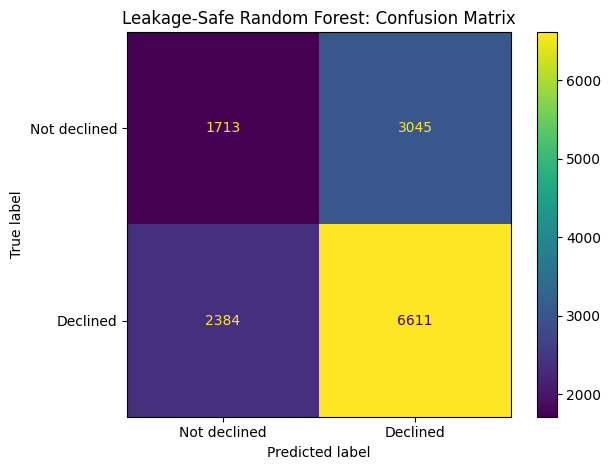

In [27]:
# ============================================
# 4B. CONFUSION MATRIX
# ============================================

import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=["Not declined", "Declined"]
)

plt.title("Leakage-Safe Random Forest: Confusion Matrix")
plt.tight_layout()
plt.show()

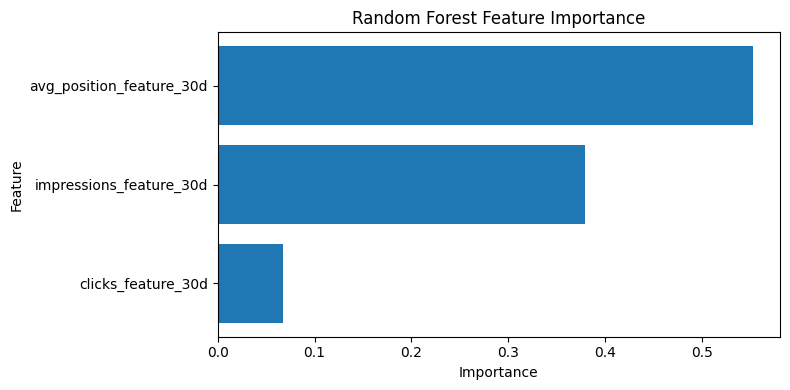

In [28]:
# ============================================
# 4C. FEATURE IMPORTANCE
# ============================================

importance_plot = importance.sort_values("importance")

plt.figure(figsize=(8, 4))

plt.barh(
    importance_plot["feature"],
    importance_plot["importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")
plt.tight_layout()
plt.show()

### Interpretation

The leakage-safe Random Forest achieved 60.52% accuracy and a ROC-AUC of 0.5799 on the held-out client groups. This was below the 64.35% accuracy of the majority-class baseline.

The model therefore did not demonstrate useful predictive improvement over the simple baseline under this validation design.

Among the three historical features, average position had the highest model-reported feature importance (55.29%), followed by impressions (37.95%) and clicks (6.75%). These values describe how the fitted Random Forest used the available features; they do not establish causation.

The result is directional and decision-support oriented. It suggests that these three historical signals alone are insufficient for reliable prediction of future impression decline across unseen clients.

## 5. Limitations

*What this work cannot claim.*

### Limitations

- The model uses only three historical signals: impressions, clicks, and average search position.
- The Random Forest did not outperform the majority-class baseline on accuracy in the held-out client evaluation.
- The ROC-AUC of 0.5799 indicates limited discrimination between future declines and non-declines.
- The grouped validation used 40 training clients and 10 unseen testing clients, so results should not be generalized beyond similar settings.
- Feature importance describes model behavior and does not establish that a feature causes impression decline.
- The analysis identifies directional patterns for decision support; it does not predict Google's ranking algorithm or guarantee that a content item will decline.
- The dataset contains anonymized identifiers and does not provide information about the underlying client businesses or private queries.

## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

### Ranked recommendations

Based on the measured results, the following actions are recommended:

**1. Treat average search position as the strongest observed signal.**  
The Random Forest assigned the highest feature importance to `avg_position_feature_30d` (55.29%). Monitoring changes in historical average position may therefore be useful when reviewing content performance.

**2. Monitor historical impression levels.**  
`impressions_feature_30d` contributed 37.95% of the model's feature importance. Large changes in historical impressions can provide useful context when assessing content performance.

**3. Use clicks as a supporting signal rather than the primary signal.**  
`clicks_feature_30d` had the lowest feature importance at 6.75% among the three available features.

**4. Do not use this model as an automatic decision rule.**  
Because the Random Forest achieved 60.52% accuracy compared with the 64.35% majority-class baseline, it should not currently be treated as a reliable production predictor of future decline.

**5. Expand the feature set before attempting production use.**  
The weak predictive performance suggests that additional leakage-safe signals should be investigated, particularly features describing query mix, content characteristics, and other historical patterns that are available before the prediction window.

### Decision rule

For the current experiment, the appropriate decision is **monitoring and further investigation rather than automated intervention**. The evidence is not strong enough to recommend taking action on individual content items solely from this model.

## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

In [29]:
# ============================================
# 7. ARTIFACTS THE PAPER EMBEDS
# ============================================

print("=== CAPSTONE ARTIFACTS ===")

print("\n1. Model vs baseline")
print(f"Baseline accuracy: {0.6435:.4f} (64.35%)")
print(f"Random Forest accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"Random Forest ROC-AUC: {roc_auc:.4f}")

print("\n2. Confusion matrix")
print("True negatives:  1,713")
print("False positives: 3,045")
print("False negatives: 2,384")
print("True positives:  6,611")

print("\n3. Feature importance")
display(importance)

print("\n4. Validation")
print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))
print("Training clients: 40")
print("Testing clients: 10")
print("Client overlap: 0")

=== CAPSTONE ARTIFACTS ===

1. Model vs baseline
Baseline accuracy: 0.6435 (64.35%)
Random Forest accuracy: 0.6052 (60.52%)
Random Forest ROC-AUC: 0.5799

2. Confusion matrix
True negatives:  1,713
False positives: 3,045
False negatives: 2,384
True positives:  6,611

3. Feature importance


,feature,importance
2,avg_position_feature_30d,0.552932
0,impressions_feature_30d,0.379523
1,clicks_feature_30d,0.067546



4. Validation
Training rows: 97494
Testing rows: 13753
Training clients: 40
Testing clients: 10
Client overlap: 0


## Self-check

Before you submit, confirm each line honestly:

- [x] Every section above is filled — markdown thinking AND the code that backs it
- [x] The notebook runs top to bottom with no errors (Runtime → Run all)
- [x] No client names, URLs, or private queries anywhere
- [x] My claims use careful words: observed, measured, directional, decision-support
- [x] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.